In [1]:
import sys, os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/scoring"
    !pip install -q interpret shap fairlearn lightgbm xgboost
else:
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))

sys.path.insert(0, PROJECT_ROOT)
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODELS_DIR = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR = os.path.join(PROJECT_ROOT, "reports")

# Phase 5: Dashboard Preparation

## 5.1 Select best model for deployment

=== Phase 2 — All 75 Features ===
              AUROC     AUPRC        F1  Balanced Accuracy
LR         0.555366  0.231668  0.307997           0.539311
XGB        0.714057  0.391778  0.442639           0.655488
LGBM       0.720402  0.400716  0.447061           0.660384
EBM        0.720627  0.398719  0.447420           0.660212
NeuralNet  0.721528  0.398087  0.448276           0.660677

=== Phase 3 — Top 10 Features ===
              AUROC     AUPRC        F1  Balanced Accuracy
EBM        0.714183  0.390049  0.442067           0.655478
PLTR       0.639455  0.313403  0.384920           0.601286
LR         0.708492  0.379135  0.438178           0.652361
XGB        0.707259  0.382935  0.437019           0.650439
LGBM       0.713536  0.391295  0.441268           0.655040
NeuralNet  0.714824  0.390645  0.442284           0.656108

Best model for deployment: NeuralNet (AUROC=0.7148)


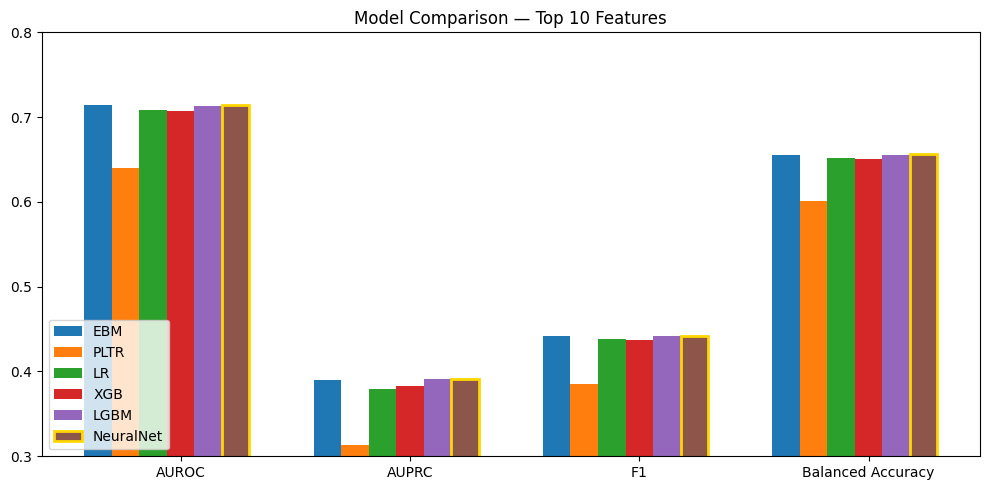

In [2]:
import pandas as pd, numpy as np, joblib, warnings, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from src.evaluate import compute_metrics, metrics_table

# Load results from Phase 2 and Phase 3
baseline = pd.read_csv(os.path.join(REPORTS_DIR, "baseline_results_optimal.csv"), index_col=0)
reduced = pd.read_csv(os.path.join(REPORTS_DIR, "reduced_results.csv"), index_col=0)
thresholds = pd.read_csv(os.path.join(REPORTS_DIR, "optimal_thresholds.csv"), index_col=0).squeeze()

print("=== Phase 2 — All 75 Features ===")
print(baseline.to_string())
print("\n=== Phase 3 — Top 10 Features ===")
print(reduced.to_string())

# Select best model for dashboard deployment
# Criteria: top 10 features (interpretable), best AUROC
best_model_name = reduced["AUROC"].idxmax()
print(f"\nBest model for deployment: {best_model_name} (AUROC={reduced.loc[best_model_name, 'AUROC']:.4f})")

# Visualization: model comparison
fig, ax = plt.subplots(figsize=(10, 5))
metrics = ["AUROC", "AUPRC", "F1", "Balanced Accuracy"]
x = np.arange(len(metrics))
width = 0.12
for i, model in enumerate(reduced.index):
    vals = [reduced.loc[model, m] for m in metrics]
    offset = (i - len(reduced.index)/2) * width
    bars = ax.bar(x + offset, vals, width, label=model)
    if model == best_model_name:
        for bar in bars:
            bar.set_edgecolor("gold"); bar.set_linewidth(2)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_title("Model Comparison — Top 10 Features")
ax.legend(loc="lower left"); ax.set_ylim(0.3, 0.8)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "model_selection.png"), dpi=150, bbox_inches="tight")
plt.show()

## 5.2 Save model + SHAP explainer artifacts

In [3]:
# Save deployment artifacts: EBM model + XGBoost (for SHAP) + metadata
import shap

top10 = pd.read_csv(os.path.join(REPORTS_DIR, "top10_features.csv")).squeeze().tolist()
# Both ebm_top10.pkl and xgb_top10.pkl are sklearn Pipelines (pre + clf)
ebm = joblib.load(os.path.join(MODELS_DIR, "ebm_top10.pkl"))
xgb = joblib.load(os.path.join(MODELS_DIR, "xgb_top10.pkl"))

# Extract the XGBoost clf step for TreeExplainer (Pipelines not directly supported)
xgb_clf = xgb.named_steps["clf"]
xgb_pre = xgb.named_steps["pre"]

# Compute SHAP explainer for XGBoost clf (used in dashboard for waterfall charts)
explainer = shap.TreeExplainer(xgb_clf)

# Load test data for SHAP background — X_test_raw.csv is the raw DataFrame input
X_test = pd.read_csv(os.path.join(DATA_DIR, "processed", "X_test_raw.csv"))
X_test_10 = X_test[top10]

# Save deployment bundle
deploy = {
    "model_name": "EBM (top 10)",
    "features": top10,
    "threshold": float(thresholds.get("EBM", 0.1745)),
    "feature_descriptions": {
        "int_rate": "Interest rate (%)",
        "term": "Loan term (months)",
        "acc_open_past_24mths": "Accounts opened in last 24 months",
        "annual_inc": "Annual income ($)",
        "dti": "Debt-to-income ratio",
        "fico": "FICO score",
        "loan_amnt": "Loan amount ($)",
        "tot_hi_cred_lim": "Total high credit limit ($)",
        "avg_cur_bal": "Average current balance ($)",
        "total_bc_limit": "Total bankcard credit limit ($)",
    },
}
joblib.dump(deploy, os.path.join(MODELS_DIR, "deploy_config.pkl"))
joblib.dump(explainer, os.path.join(MODELS_DIR, "shap_explainer.pkl"))

print("Deployment artifacts saved:")
print(f"  deploy_config.pkl — model metadata, features, threshold")
print(f"  shap_explainer.pkl — XGBoost clf SHAP explainer for waterfall charts")
print(f"  ebm_top10.pkl — EBM Pipeline (already saved)")
print(f"  xgb_top10.pkl — XGBoost Pipeline for SHAP (already saved)")

Deployment artifacts saved:
  deploy_config.pkl — model metadata, features, threshold
  shap_explainer.pkl — XGBoost clf SHAP explainer for waterfall charts
  ebm_top10.pkl — EBM Pipeline (already saved)
  xgb_top10.pkl — XGBoost Pipeline for SHAP (already saved)


## 5.3 Test prediction pipeline end-to-end

=== Test Borrower ===
  Interest rate (%): 13.5
  Loan term (months): 36.0
  Accounts opened in last 24 months: 4.0
  Annual income ($): 65000.0
  Debt-to-income ratio: 18.5
  FICO score: 690.0
  Loan amount ($): 15000.0
  Total high credit limit ($): 120000.0
  Average current balance ($): 8500.0
  Total bankcard credit limit ($): 25000.0

Default probability: 0.1401
Threshold: 0.1745
Decision: APPROVED


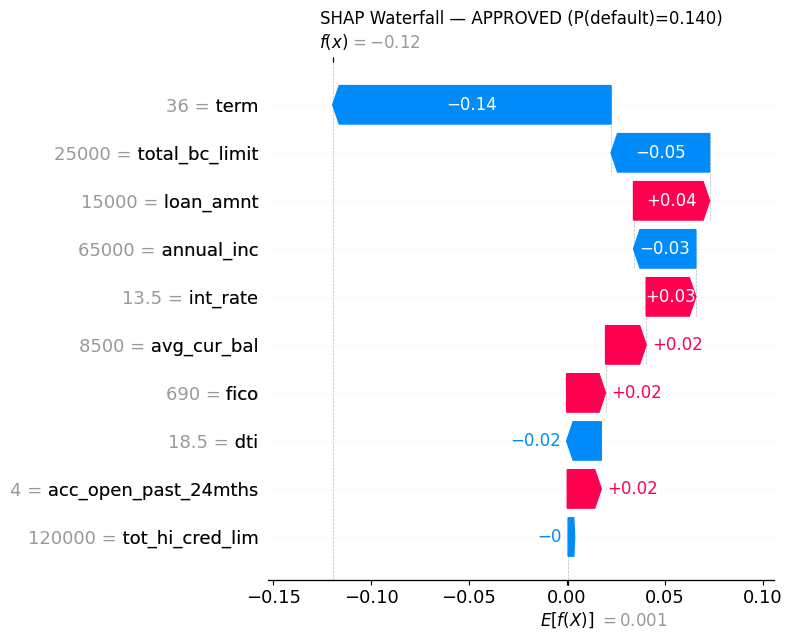


Phase 5 notebook complete. Dashboard ready at: app/dashboard.py
Run with: streamlit run app/dashboard.py


In [4]:
# End-to-end test: simulate a single borrower prediction
import shap

test_borrower = {
    "int_rate": 13.5,
    "term": 36.0,          # float to match Pipeline fit dtype
    "acc_open_past_24mths": 4.0,
    "annual_inc": 65000.0,
    "dti": 18.5,
    "fico": 690.0,
    "loan_amnt": 15000.0,
    "tot_hi_cred_lim": 120000.0,
    "avg_cur_bal": 8500.0,
    "total_bc_limit": 25000.0,
}
X_borrower = pd.DataFrame([test_borrower])

# EBM prediction — Pipeline accepts raw DataFrame directly
prob = ebm.predict_proba(X_borrower)[:, 1][0]
decision = "DENIED" if prob >= deploy["threshold"] else "APPROVED"
print(f"=== Test Borrower ===")
for k, v in test_borrower.items():
    print(f"  {deploy['feature_descriptions'][k]}: {v}")
print(f"\nDefault probability: {prob:.4f}")
print(f"Threshold: {deploy['threshold']:.4f}")
print(f"Decision: {decision}")

# SHAP waterfall for this prediction
# Must preprocess through xgb_pre before passing to the clf-level TreeExplainer
X_borrower_pre = xgb_pre.transform(X_borrower)
shap_vals = explainer.shap_values(X_borrower_pre)

# Map preprocessed feature names back to top10 names for display
feat_names_pre = list(xgb_pre.get_feature_names_out())
# Aggregate OHE columns per original feature
shap_aggregated = np.zeros(len(top10))
data_aggregated = np.zeros(len(top10))
for j, feat in enumerate(top10):
    cols = [k for k, name in enumerate(feat_names_pre)
            if name == f"num__{feat}" or name == f"count__{feat}" or name == f"pct__{feat}"
            or name.startswith(f"cat__{feat}_")]
    if cols:
        shap_aggregated[j] = shap_vals[0, cols].sum()
        data_aggregated[j] = test_borrower[feat]

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_aggregated,
        base_values=float(explainer.expected_value),
        data=data_aggregated,
        feature_names=top10,
    ),
    show=False,
)
plt.title(f"SHAP Waterfall — {decision} (P(default)={prob:.3f})")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "shap_waterfall_example.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\nPhase 5 notebook complete. Dashboard ready at: app/dashboard.py")
print("Run with: streamlit run app/dashboard.py")